# Getting Data

In [ ]:
import numpy as np
import pandas as pd
light_df = pd.read_csv("my26sources.csv")

coords = SkyCoord(
    ra=light_df["RA"].values * u.deg,
    dec=light_df["Dec"].values * u.deg,
    frame="icrs")

radius = 1.5 * u.arcsec
columns = ['ra', 'dec', 'w1mpro', 'w2mpro', 'w1sigmpro', 'w2sigmpro', 'mjd']

wise_results = []

def query_wise(galaxy_name, coord):
    """Query NEOWISE-R for a single galaxy."""
    try:
        result = Irsa.query_region(
            coord,
            catalog='neowiser_p1bs_psd',
            spatial='Cone',
            radius=radius,
        )
        if len(result) == 0:
            print(f"No WISE data found for {galaxy_name}")
            return None
        df = result.to_pandas()[columns]
        df['Name'] = galaxy_name
        return df
    except Exception as e:
        print(f"Error querying {galaxy_name}: {e}")
        return None

In [ ]:
with ThreadPoolExecutor(max_workers=10) as executor:

    futures = [
        executor.submit(query_wise, f"Source_{i+1}", coord)
        for i, coord in enumerate(coords)
    ]

    for future in as_completed(futures):
        df = future.result()
        if df is not None:
            wise_results.append(df)

wise_dfquery = pd.concat(wise_results, ignore_index=True)

# Cleaning Data

In [ ]:
df = wise_dfquery

import pandas as pd
import numpy as np

INPUT_CSV  = df
OUTPUT_CSV = "cleaned_binned_lightcurves26.csv"

EPOCH_LENGTH = 180.0   # dps (NEOWISE cadence)
MAD_THRESHOLD = 3.0    # outlier cutoff



# MAD OUTLIER FILTER
def mad_filter(values, threshold=MAD_THRESHOLD):
    values = np.asarray(values)
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))

    if mad == 0 or np.isnan(mad):
        return np.ones(len(values), dtype=bool)

    return np.abs(values - median) <= threshold * mad



# MAIN CLEANING FUNCTION
def clean_and_bin(df, mag_col, err_col, band_name):
    results = []

    for name, group in df.groupby("Name"):
        mjd_min = group["mjd"].min()
        group = group.copy()

        # Assign NEOWISE epoch index
        group["epoch"] = np.floor((group["mjd"] - mjd_min) / EPOCH_LENGTH)

        for ep, ep_group in group.groupby("epoch"):
            mags = ep_group[mag_col].values
            errs = ep_group[err_col].values if err_col in ep_group else None

            valid = ~np.isnan(mags)
            mags = mags[valid]
            errs = errs[valid] if errs is not None else None

            if len(mags) == 0:
                continue

            # Outlier mask (computed on mags)
            keep = mad_filter(mags)

            mags_clean = mags[keep]
            errs_clean = errs[keep] if errs is not None else None

            if len(mags_clean) == 0:
                continue

            # Mean magnitude
            mag_mean = np.mean(mags_clean)
            mag_std = np.std(mags_clean)
            mjd_clean = ep_group["mjd"].values[valid][keep]
            mjd_mean = np.mean(mjd_clean)


            results.append({
                "Name": name,
                "band": band_name,
                "epoch": int(ep),
                "mjd_mean": mjd_mean,
                "mag_mean": mag_mean,
                "mag_err_mean": mag_std,
                "n_raw": len(mags),
                "n_used": len(mags_clean),
                #"n_err_used": n_err
            })

    return pd.DataFrame(results)



# PROCESS W1 AND W2
w1_df = df[["Name", "mjd", "w1mpro", "w1sigmpro"]].copy()
w2_df = df[["Name", "mjd", "w2mpro", "w2sigmpro"]].copy()

w1_clean = clean_and_bin(w1_df, "w1mpro", "w1sigmpro", "W1")
w2_clean = clean_and_bin(w2_df, "w2mpro", "w2sigmpro", "W2")

# COMBINE & SAVE
cleaned = pd.concat([w1_clean, w2_clean], ignore_index=True)
cleaned.to_csv(OUTPUT_CSV, index=False)

print(f"Saved cleaned, epoch-binned light curves to {OUTPUT_CSV}")

In [ ]:
import pandas as pd

cb = pd.read_csv("cleaned_binned_lightcurves26.csv")

# Keep only rows for W1 and W2, then filter bins with n_used >= 3
w1w2_df = cb[cb['band'].isin(['W1', 'W2'])].copy()
w1w2_filtered = w1w2_df[w1w2_df['n_used'] >= 3].copy()

# Reset index for cleanliness
w1w2_filtered.reset_index(drop=True, inplace=True)

# Save to a new CSV
w1w2_filtered.to_csv('26filteredn.csv', index=False)

# Per-band counts for a clearer before/after picture
for band in ['W1', 'W2']:
    orig_count = len(cb[cb['band'] == band])
    filt_count = len(w1w2_filtered[w1w2_filtered['band'] == band])
    print(f"Original {band} rows: {orig_count}")
    print(f"Filtered {band} rows: {filt_count}")

# Adding W3

In [ ]:
from astroquery.ipac.irsa import Irsa
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd

# --- 1. Updated query function: grab mag, error, and mean MJD ---

light_df = pd.read_csv("my26sources.csv")
coords = SkyCoord(
    ra=light_df["RA"].values * u.deg,
    dec=light_df["Dec"].values * u.deg,
    frame="icrs")
radius = 1.5 * u.arcsec

def query_w3(name, coord):
    try:
        result = Irsa.query_region(
            coord,
            catalog="allwise_p3as_psd",
            spatial="Cone",
            radius=radius
        )
        if len(result) == 0:
            print(f"No AllWISE match for {name}")
            return None
        df = result.to_pandas()
        if "dist" in df.columns:
            df = df.sort_values("dist")
        row = df.iloc[0]
        return {
            "Name": name,
            "w3mpro": row.get("w3mpro"),
            "w3sigmpro": row.get("w3sigmpro"),
            "w3mjdmean": row.get("w3mjdmean")
        }
    except Exception as e:
        print(f"{name}: {e}")
        return None

# (rerun your ThreadPoolExecutor block as-is — it will now populate the extra fields)
from concurrent.futures import ThreadPoolExecutor, as_completed

w3_results = []

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(query_w3, f"Source_{i+1}", coord)
        for i, coord in enumerate(coords)
    ]

    for future in as_completed(futures):
        result = future.result()
        if result is not None:
            w3_results.append(result)

w3_df = pd.DataFrame(w3_results)

# --- 2. Load your existing lightcurve dataset ---
light_curve_df = pd.read_csv("26filteredn.csv")

# --- 3. Reshape w3_df into the same schema as 26filtered.csv ---
w3_rows = pd.DataFrame({
    "Name": w3_df["Name"],
    "band": "W3",
    "epoch": 1,                          # AllWISE W3 is a single mean point, so epoch = 1
    "mjd_mean": w3_df["w3mjdmean"],
    "mag_mean": w3_df["w3mpro"],
    "mag_err_mean": w3_df["w3sigmpro"],
    "n_raw": pd.NA,                      # not tracked by AllWISE catalog-level query
    "n_used": 1
})

# --- 4. Concatenate and save ---
combined_df = pd.concat([light_curve_df, w3_rows], ignore_index=True)
combined_df = combined_df.sort_values(["Name", "band", "epoch"]).reset_index(drop=True)

combined_df.to_csv("26filtered_with_w3n.csv", index=False)
print(f"Added {len(w3_rows)} W3 rows. Final shape: {combined_df.shape}")

# Adding W2 Average

In [1]:
import pandas as pd

df = pd.read_csv("26filtered_with_w3n.csv")

w2_mean_simple = (
    df[df["band"] == "W2"]
    .groupby("Name")["mag_mean"]
    .mean()
    .rename("w2_mag_mean_overall")
)

df = df.merge(w2_mean_simple, on="Name", how="left") 

df.to_csv("26filtered_with_w3_and_w2meann.csv", index=False)

In [2]:
import pandas as pd

df = pd.read_csv("26filtered_with_w3_and_w2meann.csv")  # or whatever your file is named

# --- 1. Pivot W1 and W2 mag_mean AND mjd_mean into wide format, keyed by Name + epoch ---
w1w2 = df[df["band"].isin(["W1", "W2"])]

w1w2_wide = w1w2.pivot_table(
    index=["Name", "epoch"],
    columns="band",
    values=["mag_mean", "mjd_mean"]
).reset_index()

# Flatten the resulting MultiIndex columns (e.g. ('mag_mean', 'W1') -> 'W1_mag_mean')
w1w2_wide.columns = [
    f"{col[1]}_{col[0]}" if col[1] else col[0]
    for col in w1w2_wide.columns
]
w1w2_wide = w1w2_wide.rename(columns={"W1_mag_mean": "W1", "W2_mag_mean": "W2"})

# Use the average of W1_mjd_mean and W2_mjd_mean as a single representative MJD per epoch
w1w2_wide["mjd_mean"] = w1w2_wide[["W1_mjd_mean", "W2_mjd_mean"]].mean(axis=1)

# --- 2. Get W3 mag per source (one value per Name, from the band == 'W3' row) ---
w3_vals = df[df["band"] == "W3"][["Name", "mag_mean"]].rename(columns={"mag_mean": "w3mpro"})

# --- 3. Get w2_mag_mean_overall per source (same value repeated across all rows, so just grab once per Name) ---
w2_overall = df[["Name", "w2_mag_mean_overall"]].drop_duplicates()

# --- 4. Merge everything onto the W1/W2 wide table ---
color_df = w1w2_wide.merge(w3_vals, on="Name", how="left")
color_df = color_df.merge(w2_overall, on="Name", how="left")

# --- 5. Compute your two color columns ---
color_df["W1-W2"] = color_df["W1"] - color_df["W2"]
color_df["W2-W3"] = color_df["w2_mag_mean_overall"] - color_df["w3mpro"]

color_df.head()

,Name,epoch,W1,W2,W1_mjd_mean,W2_mjd_mean,mjd_mean,w3mpro,w2_mag_mean_overall,W1-W2,W2-W3
0,Source_1,1,10.887637,10.122889,56945.932835,56945.980007,56945.956421,7.247,9.947873,0.764748,2.700873
1,Source_1,2,10.859899,10.095182,57128.399185,57128.420671,57128.409928,7.247,9.947873,0.764717,2.700873
2,Source_1,3,10.803250,10.052727,57305.028199,57305.034157,57305.031178,7.247,9.947873,0.750523,2.700873
3,Source_1,4,10.817461,10.056572,57518.857097,57516.974381,57517.915739,7.247,9.947873,0.760889,2.700873
4,Source_1,5,10.766001,10.012301,57664.847299,57664.107055,57664.477177,7.247,9.947873,0.753700,2.700873


# Plotting

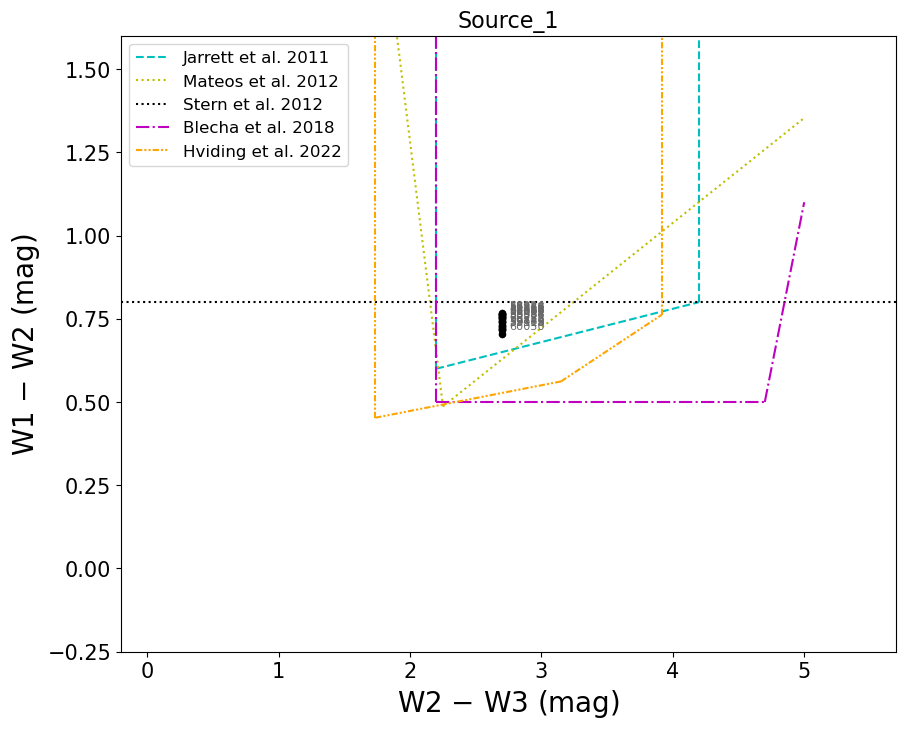

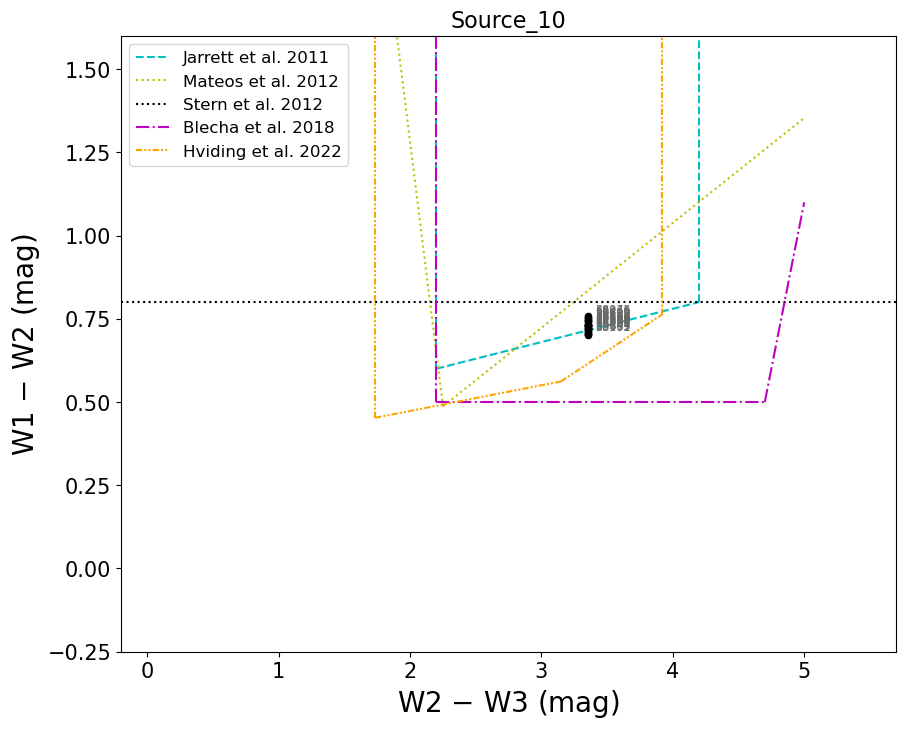

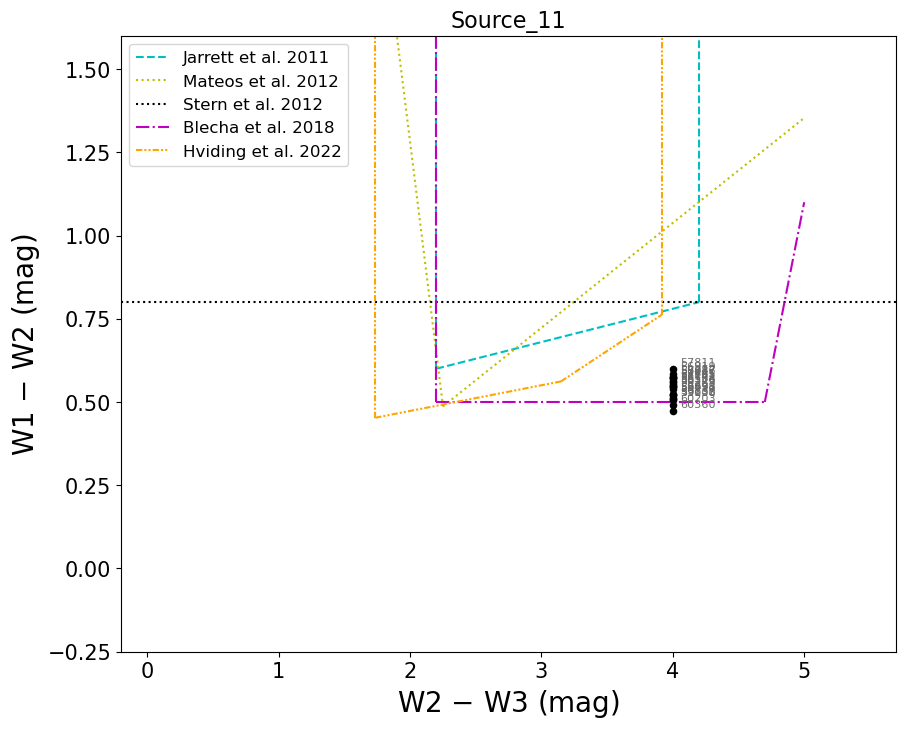

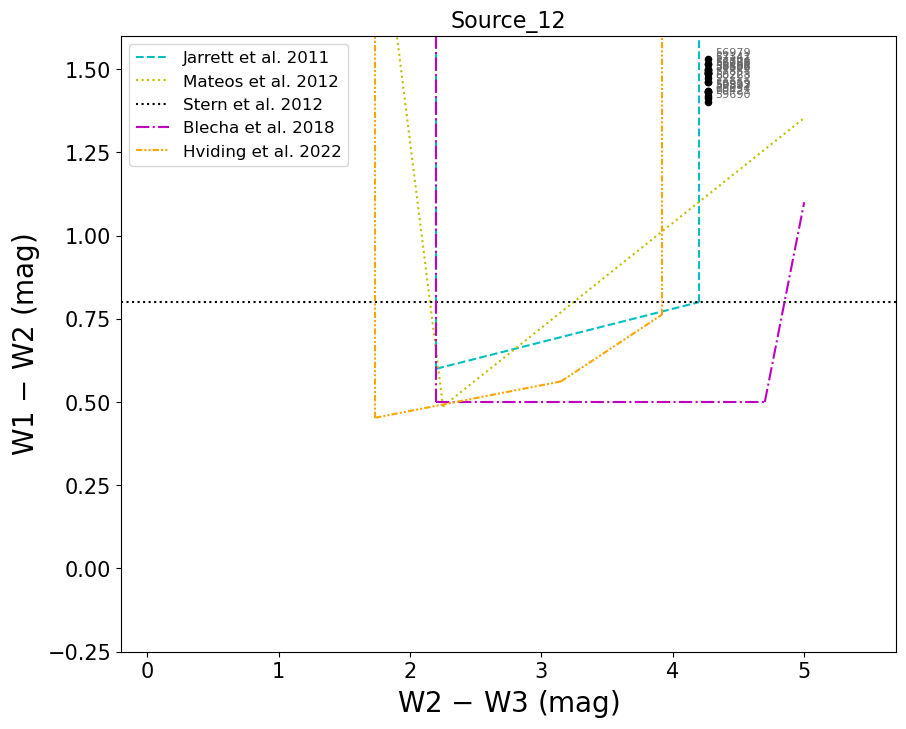

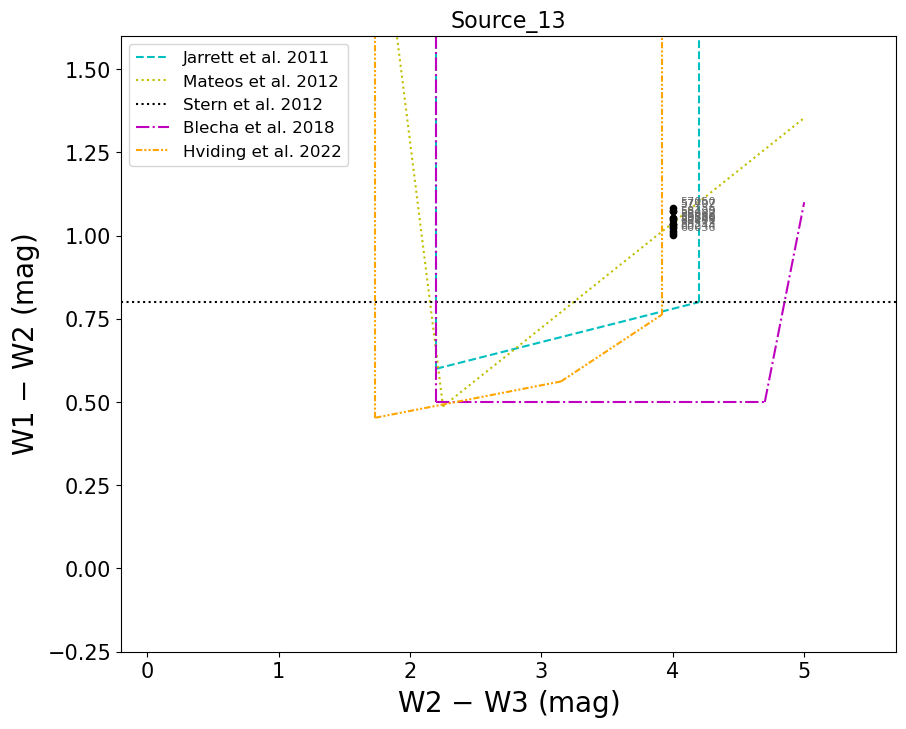

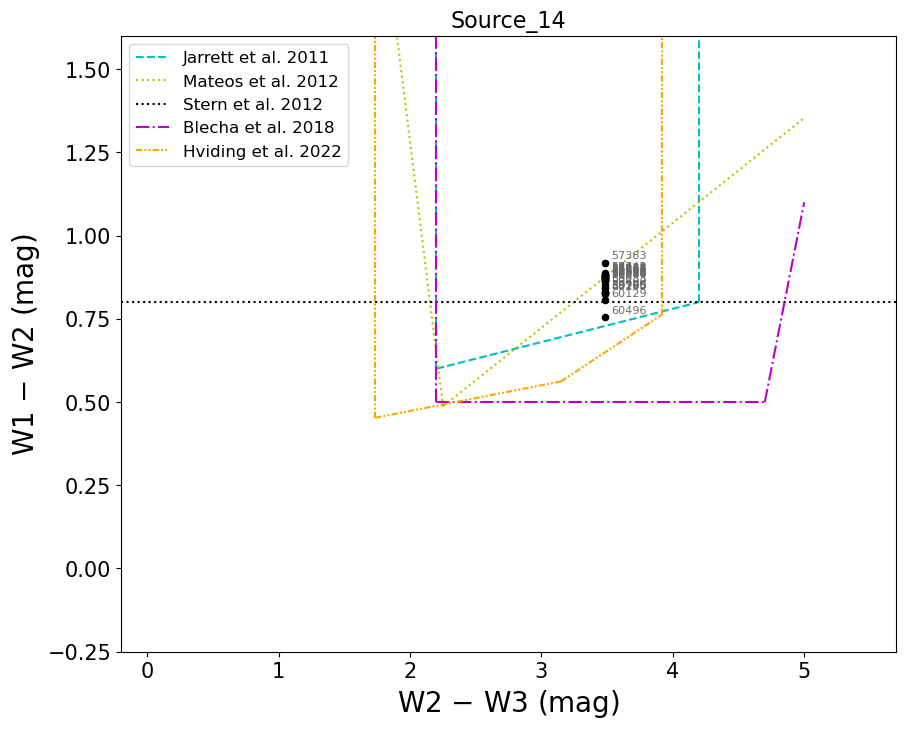

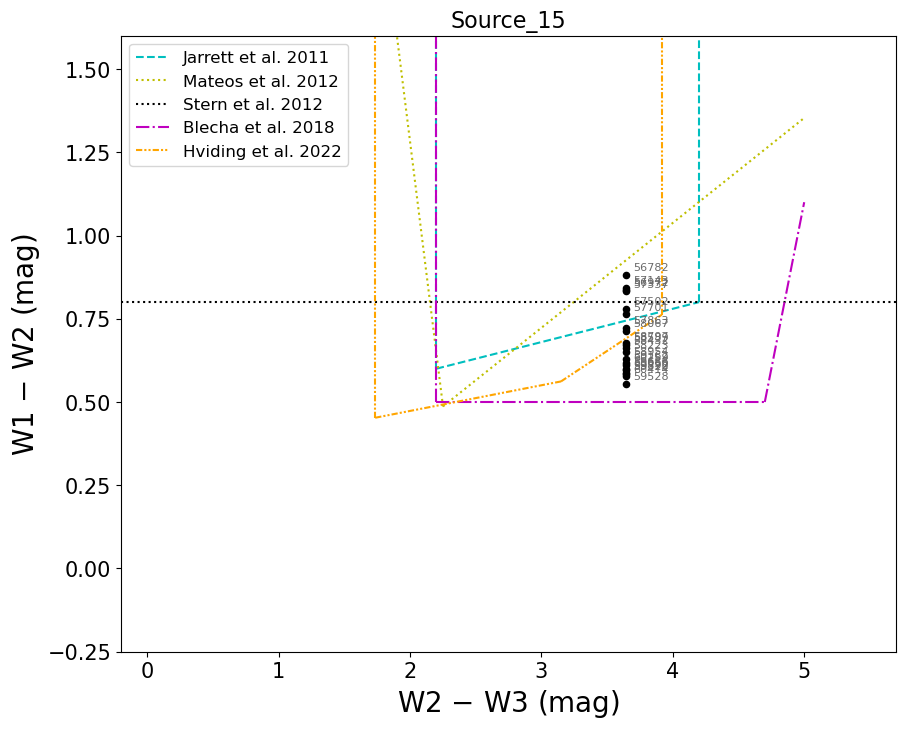

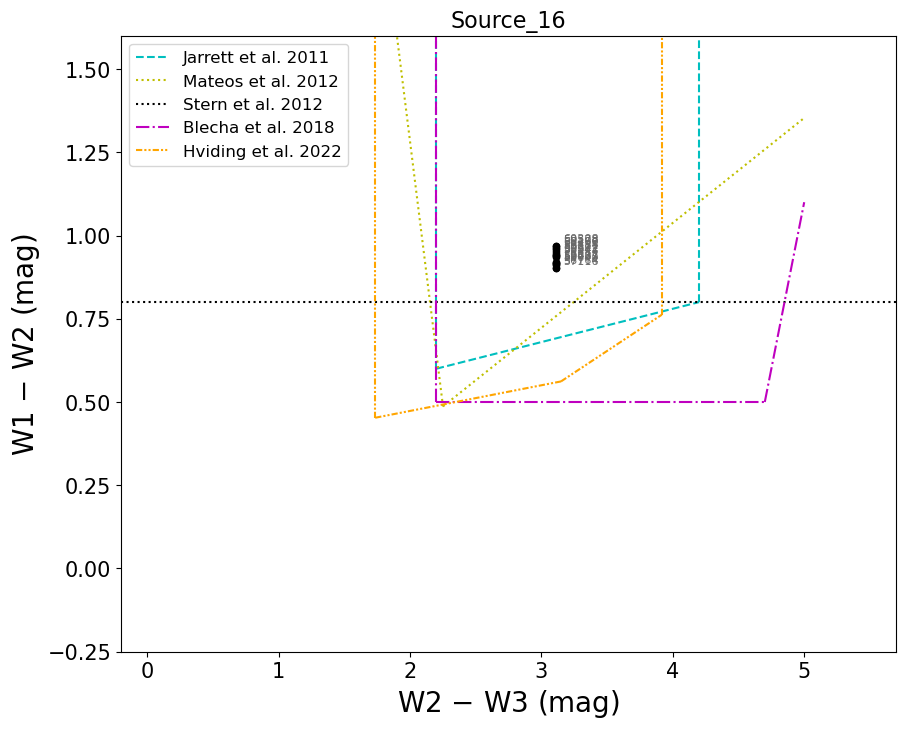

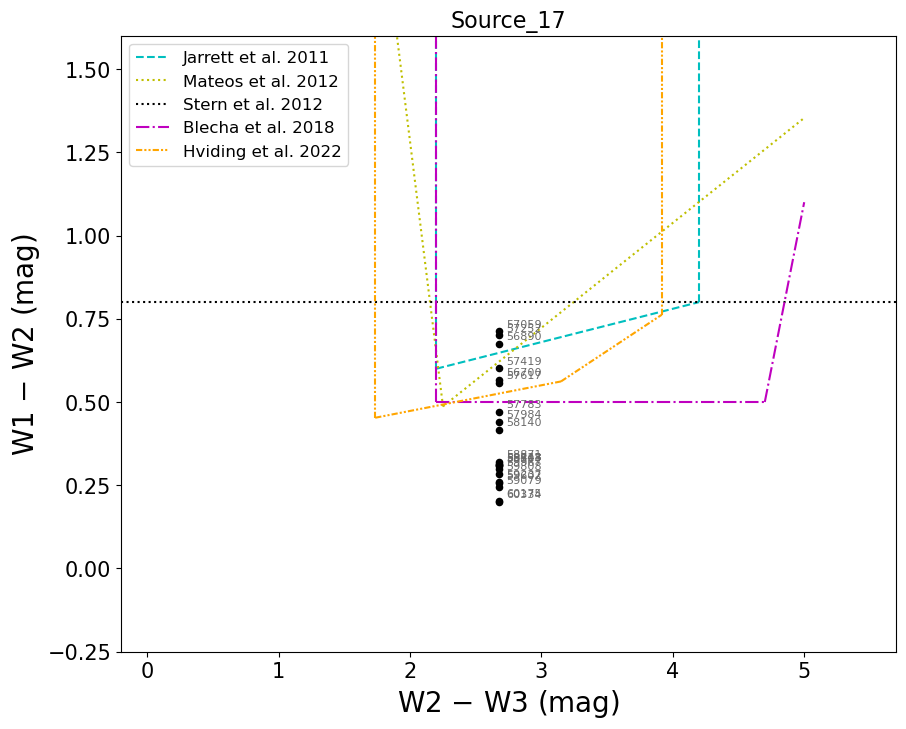

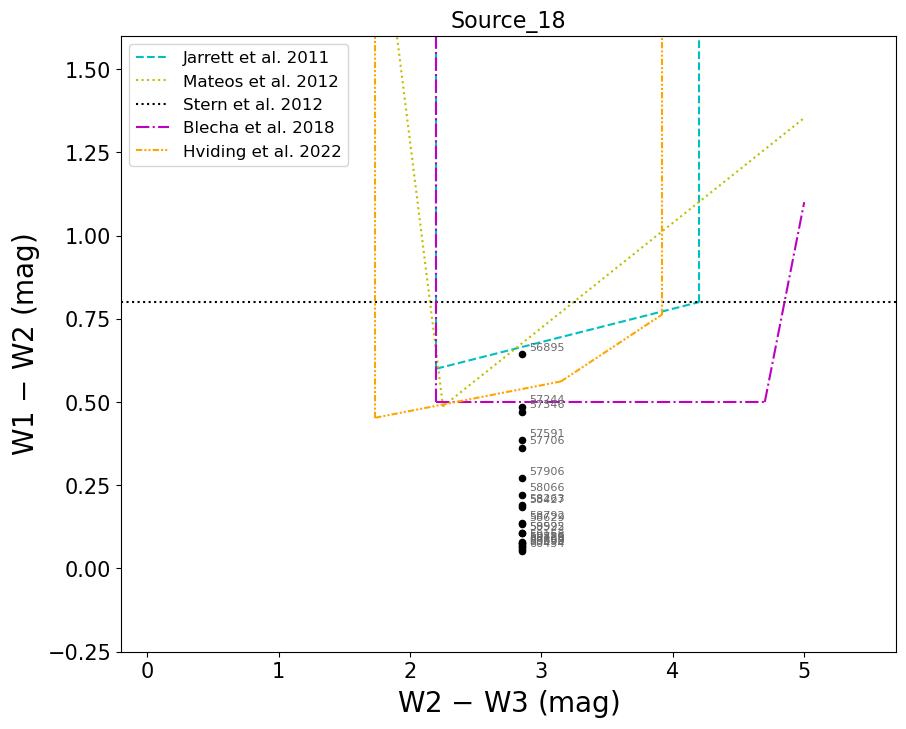

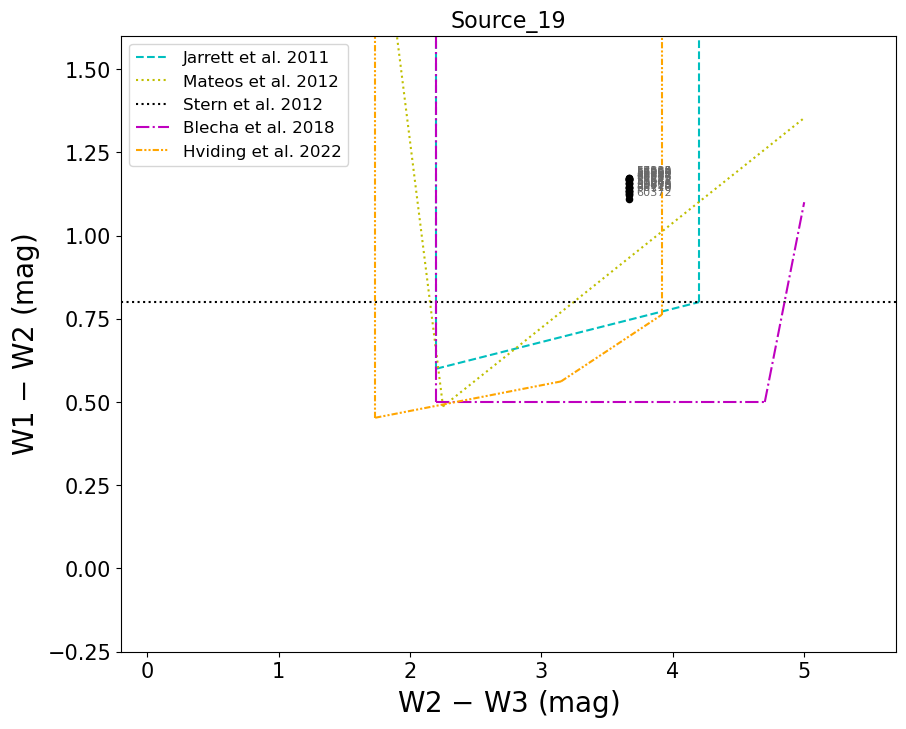

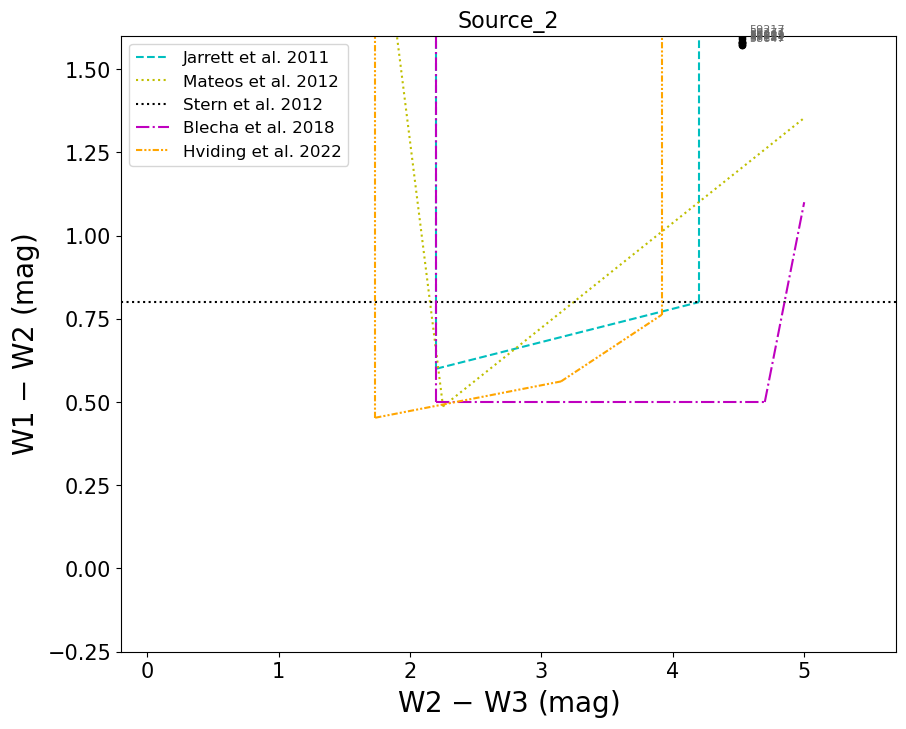

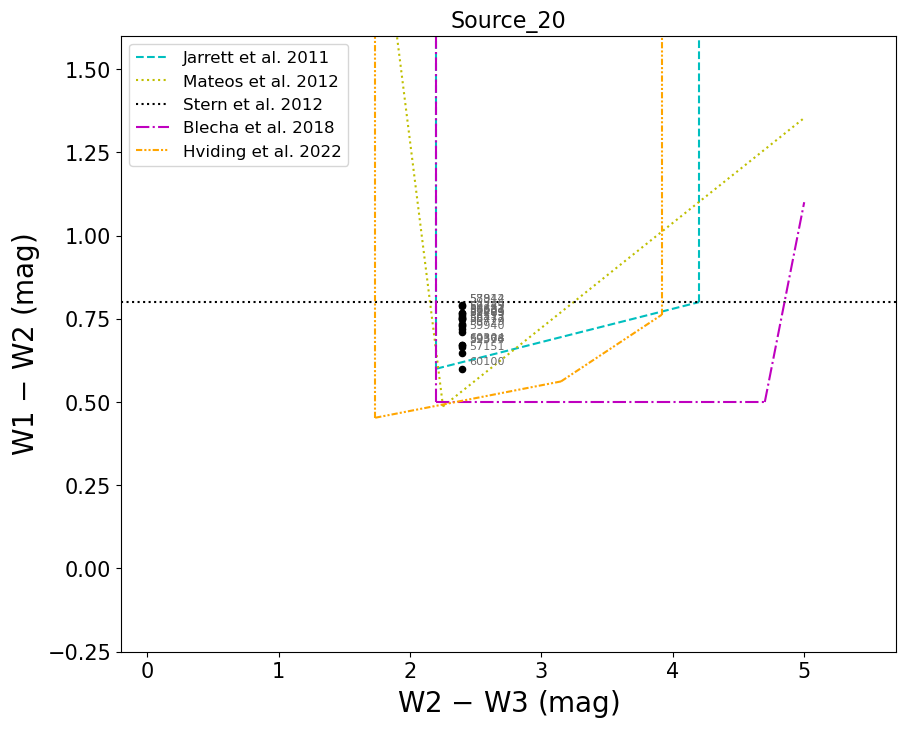

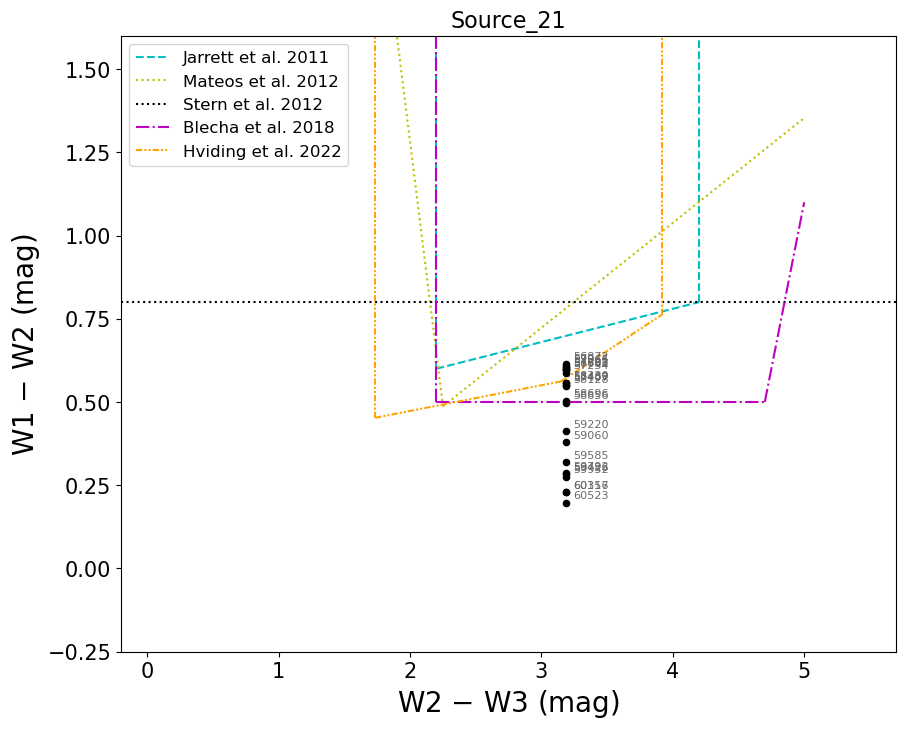

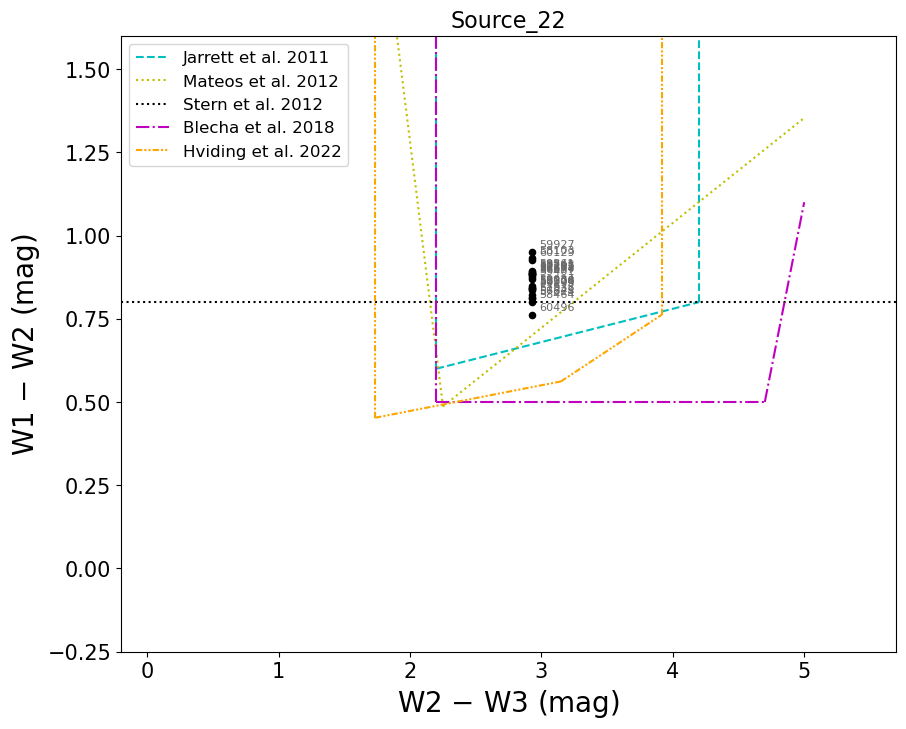

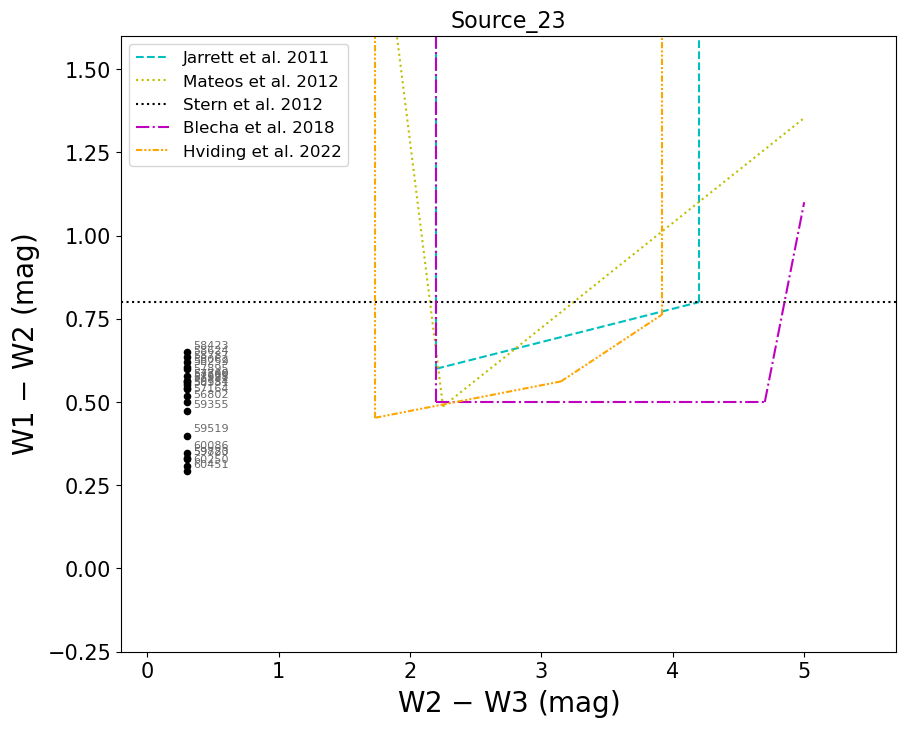

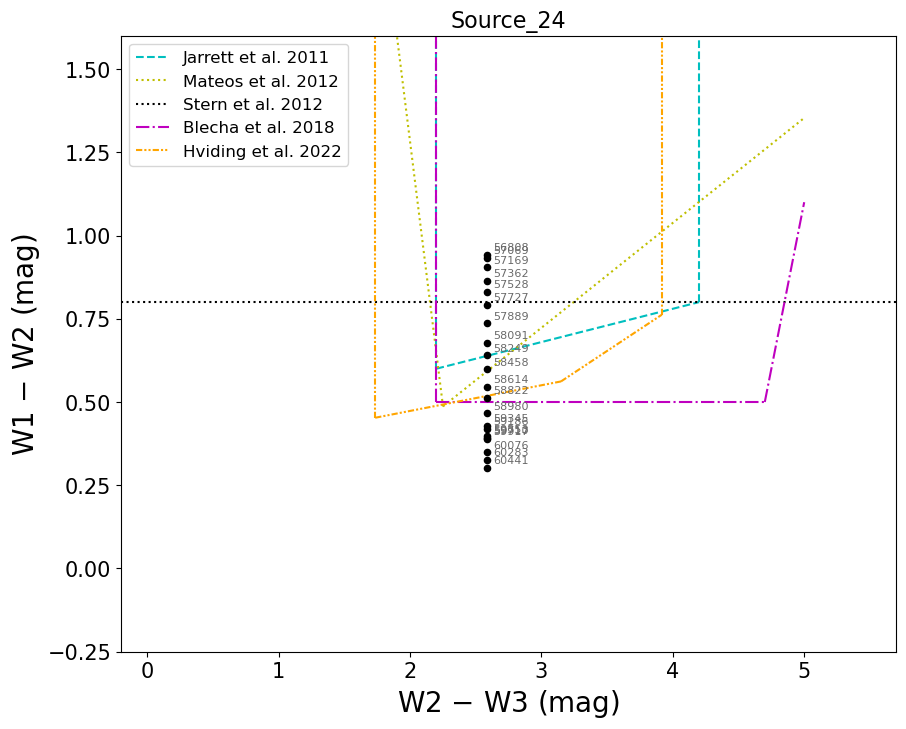

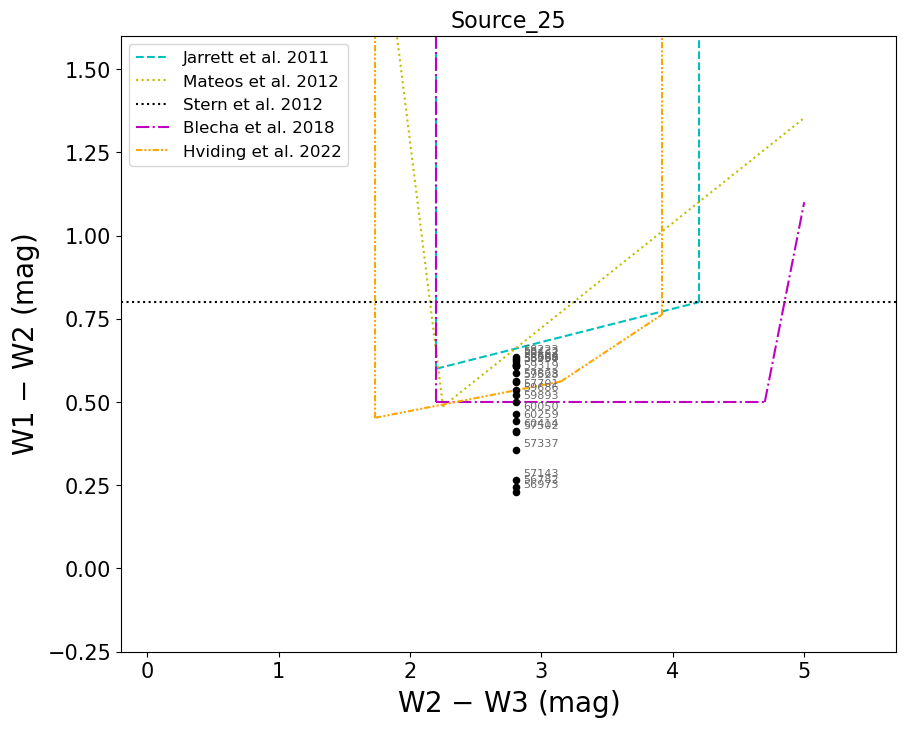

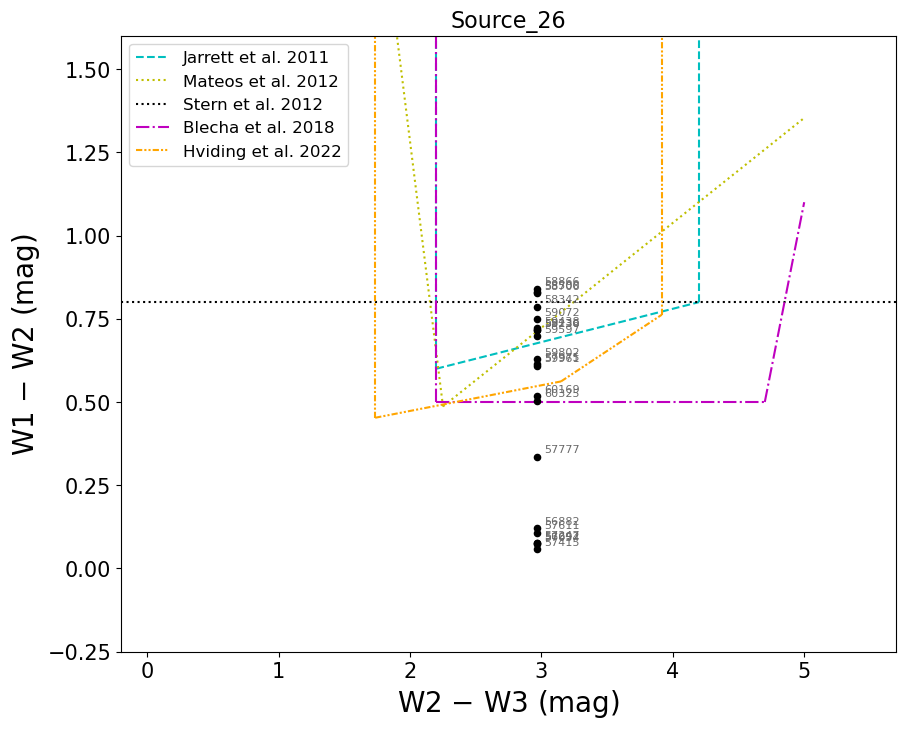

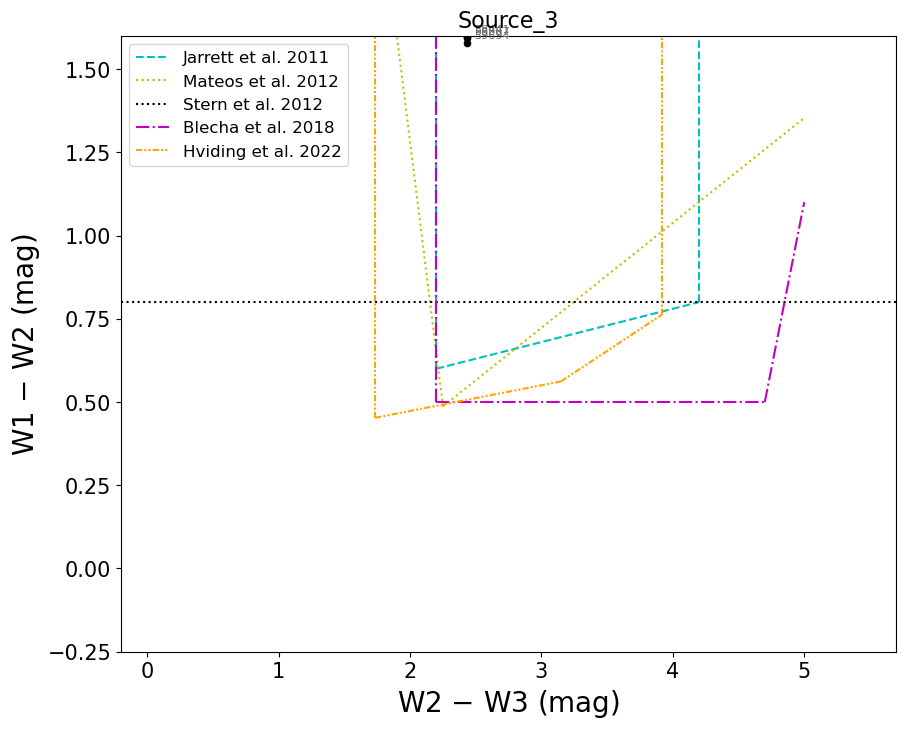

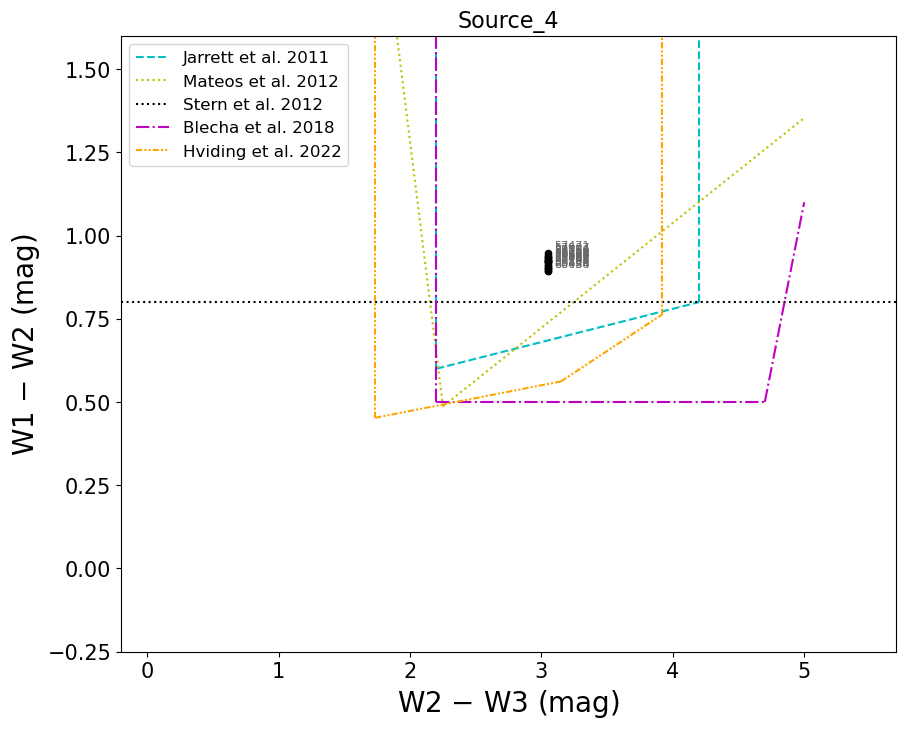

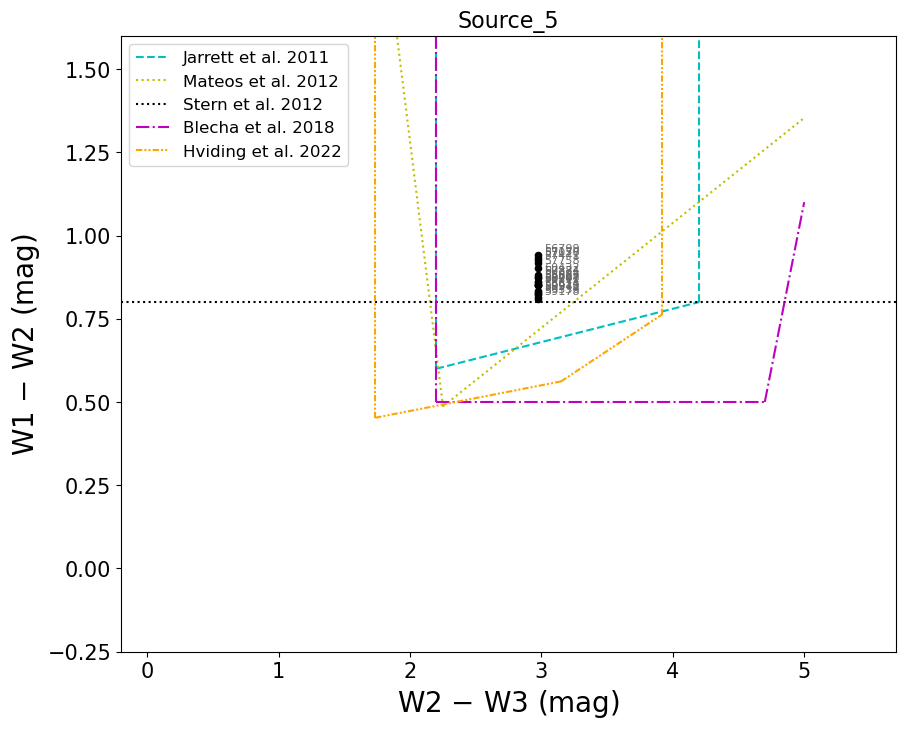

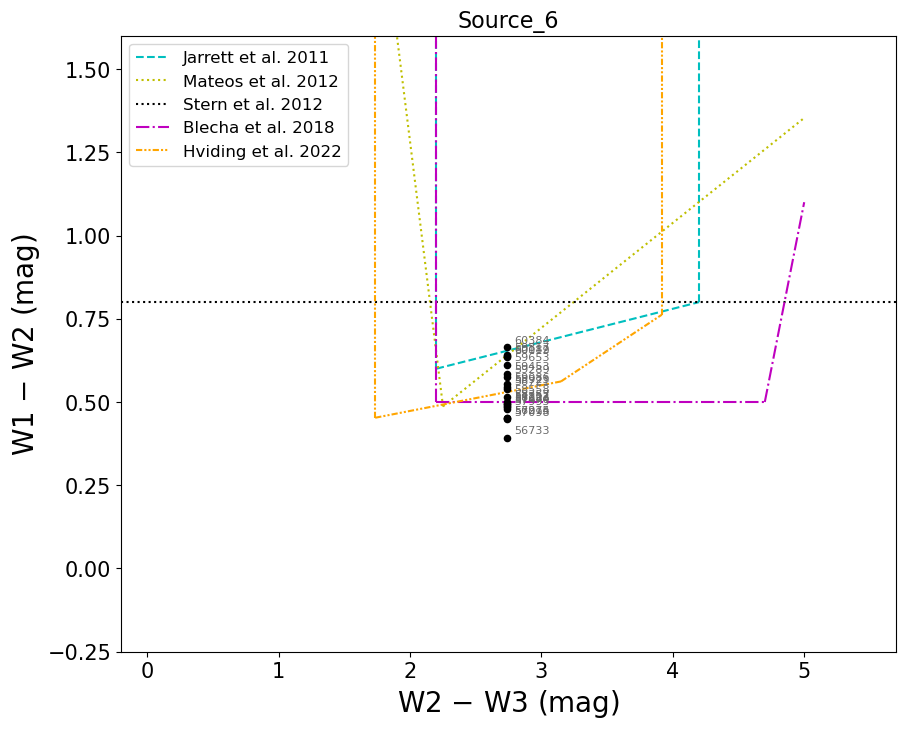

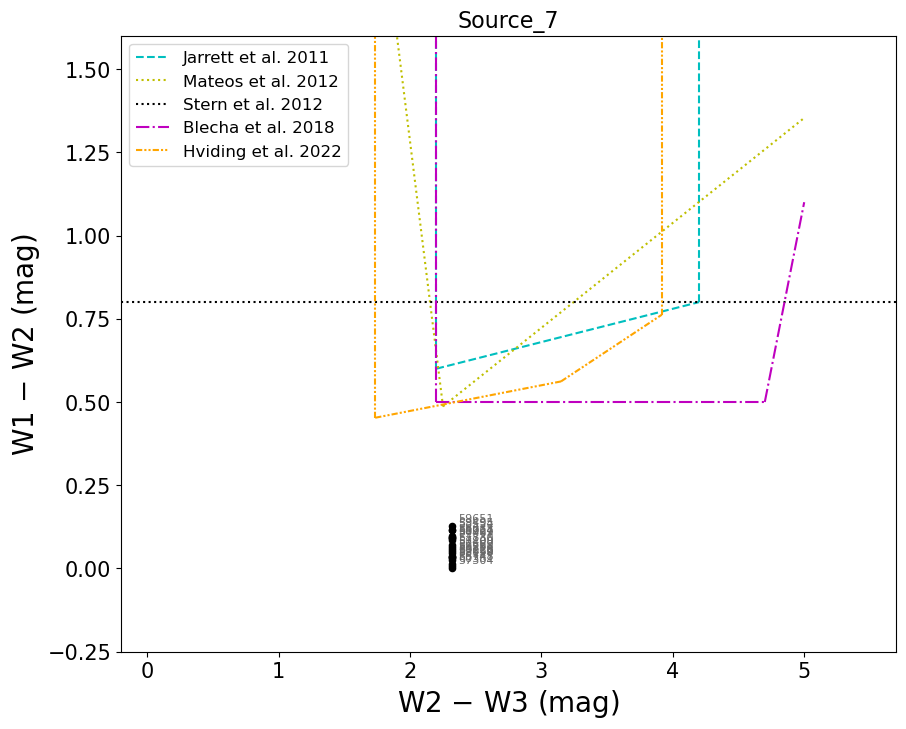

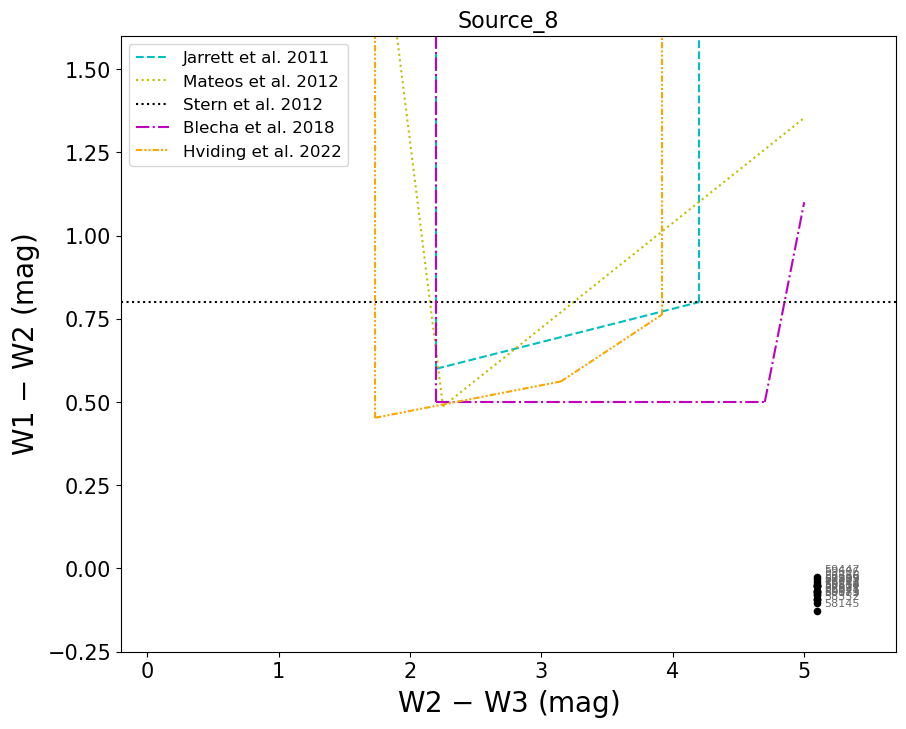

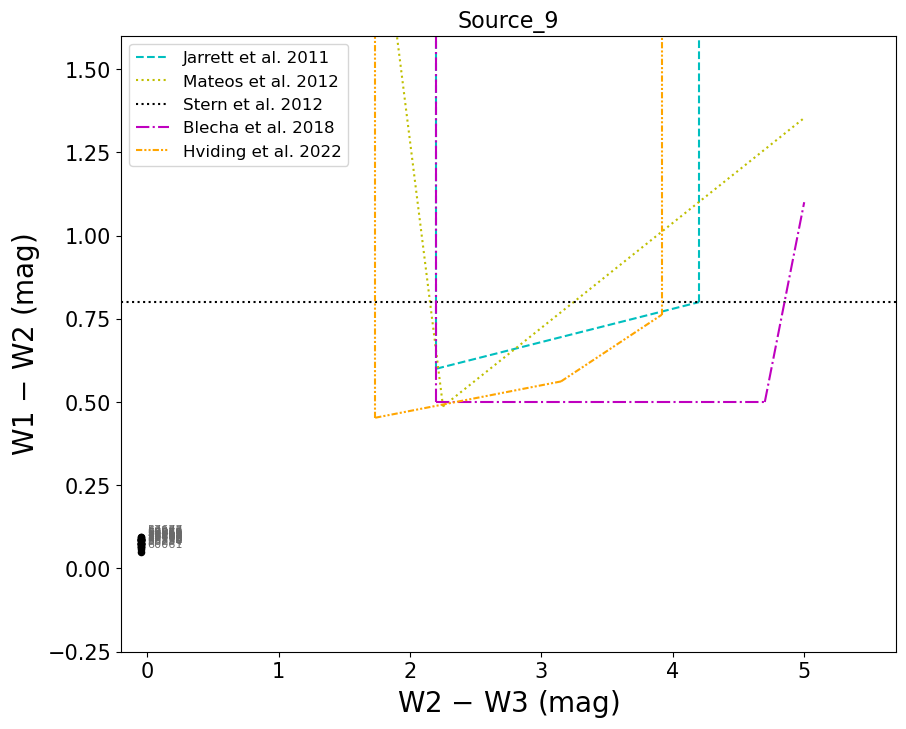

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['figure.figsize'] = 10, 8
rcParams['font.size'] = 15

def plot_source(source, color_df, save=False, outdir="."):
    fig, ax = plt.subplots()

    # --- Selection boundary lines (same for every source) ---
    x_jarrett = np.array([2.2, 4.2])
    ax.plot(x_jarrett, 0.1*x_jarrett+0.38, c='c', linestyle='dashed', label='Jarrett et al. 2011')
    ax.plot([2.2, 2.2], [0.1*2.2+0.38, 1.7], c='c', linestyle='dashed')
    ax.plot([4.2, 4.2], [0.1*4.2+0.38, 1.7], c='c', linestyle='dashed')

    x_mateos = np.array([0, (7.624 + 0.222) / (0.315 + 3.172), 5])
    ax.plot(x_mateos[:2], -3.172*x_mateos[:2]+7.624, c='y', linestyle='dotted', label='Mateos et al. 2012')
    ax.plot(x_mateos[1:], 0.315*x_mateos[1:]-0.222, c='y', linestyle='dotted')

    ax.axhline(0.8, c='k', linestyle='dotted', label='Stern et al. 2012')

    x_blecha = np.array([2.2, (8.9+0.5)/2.0, 5])
    ax.plot([2.2, 2.2], [0.5, 3.0], c='m', linestyle='dashdot', label='Blecha et al. 2018')
    ax.plot(x_blecha[:2], [0.5, 0.5], c='m', linestyle='dashdot')
    ax.plot(x_blecha[1:], 2.0*x_blecha[1:]-8.9, c='m', linestyle='dashdot')

    x_hviding = np.array([1.734, (0.319+0.260)/(0.261-0.0771), 3.916])
    ax.plot([1.734, 1.734], [0.0771*1.734+0.319, 3.0], c='orange', linestyle=(0,(3,1,1,1,1,1)),
             label='Hviding et al. 2022')
    ax.plot(x_hviding[:2], 0.0771*x_hviding[:2]+0.319, c='orange', linestyle=(0,(3,1,1,1,1,1)))
    ax.plot(x_hviding[1:], 0.261*x_hviding[1:]-0.260, c='orange', linestyle=(0,(3,1,1,1,1,1)))
    ax.plot([3.916, 3.916], [0.261*3.916-0.260, 3.0], c='orange', linestyle=(0,(3,1,1,1,1,1)))


    # --- Source-specific data ---
    df_plot = color_df[color_df["Name"] == source].dropna(subset=["W1-W2", "W2-W3"])
    ax.scatter(
        df_plot["W2-W3"],
        df_plot["W1-W2"],
        color="black",
        s=20,
        zorder=5
    )

    # --- Label each point with its MJD ---
    for _, row in df_plot.iterrows():
        ax.annotate(
            f"{row['mjd_mean']:.0f}",
            (row["W2-W3"], row["W1-W2"]),
            textcoords="offset points",
            xytext=(5, 3),       # small offset so label doesn't sit on top of the point
            fontsize=8,
            color="dimgray"
        )

    ax.set_xlabel('W2 $-$ W3 (mag)', fontsize=20)
    ax.set_ylabel('W1 $-$ W2 (mag)', fontsize=20)
    ax.set_title(source, fontsize=16)
    ax.set_xlim(-0.2, 5.7)
    ax.set_ylim(-0.25, 1.6)
    ax.legend(fontsize=12, loc='upper left')

    if save:
        fig.savefig(f"{outdir}/{source}_color_color.png", dpi=150, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

# --- Loop over all 26 sources ---
for source in sorted(color_df["Name"].unique()):
    plot_source(source, color_df, save=False)   # set save=True to write PNGs instead of displaying